## 1. Tải và Kiểm tra Dữ liệu


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải và Kiểm tra Dữ liệu
# Tải tập dữ liệu diabetes.csv vào DataFrame
df = pd.read_csv('diabetes.csv')

# Hiển thị 5 hàng đầu tiên của DataFrame
print("5 hàng đầu tiên của dữ liệu:")
print(df.head())

# Hiển thị thông tin tóm tắt của DataFrame
print("\nThông tin tóm tắt của dữ liệu:")
print(df.info())

# Kiểm tra tổng số giá trị thiếu cho mỗi cột
print("\nSố lượng giá trị thiếu cho mỗi cột:")
print(df.isnull().sum())


5 hàng đầu tiên của dữ liệu:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Thông tin tóm tắt của dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies            

## 2. Tạo Thống kê Tóm tắt Tổng thể


In [14]:
# 2. Tạo Thống kê Tóm tắt Tổng thể
# Sử dụng .describe() để tạo bảng thống kê tóm tắt cho tất cả các cột số
print("\nBảng thống kê tóm tắt tổng thể:")
print(df.describe())



Bảng thống kê tóm tắt tổng thể:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
mi

## 3. Phân tích Xu hướng Trung tâm và Độ phân tán cho Từng Đặc trưng


In [15]:
# 3. Phân tích Xu hướng Trung tâm và Độ phân tán cho Từng Đặc trưng

# Tạo một DataFrame trống để lưu trữ kết quả
summary_stats = pd.DataFrame(columns=['Feature', 'Mean', 'Median', 'Mode', 'Standard Deviation', 'Variance'])

# Lặp qua từng cột số và tính toán các thống kê
for column in df.columns:
    if df[column].dtype != 'object': # Chỉ xử lý các cột số
        mean_val = df[column].mean()
        median_val = df[column].median()
        mode_val = df[column].mode()[0] if not df[column].mode().empty else 'N/A' # Lấy mode đầu tiên nếu có
        std_dev_val = df[column].std()
        variance_val = df[column].var()
        
        summary_stats = pd.concat([
            summary_stats,
            pd.DataFrame([{
                'Feature': column,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Standard Deviation': std_dev_val,
                'Variance': variance_val
            }])
        ], ignore_index=True)

print("\nBảng phân tích Xu hướng Trung tâm và Độ phân tán:")
print(summary_stats.to_markdown(index=False))

print("\nNhận xét về độ lệch (Skewness) dựa trên Mean và Median:")
for index, row in summary_stats.iterrows():
    feature = row['Feature']
    mean_val = row['Mean']
    median_val = row['Median']
    if mean_val > median_val:
        print(f"- Phân bố của '{feature}' có vẻ bị lệch phải (Mean > Median).")
    elif mean_val < median_val:
        print(f"- Phân bố của '{feature}' có vẻ bị lệch trái (Mean < Median).")
    else:
        print(f"- Phân bố của '{feature}' có vẻ đối xứng (Mean = Median).")



Bảng phân tích Xu hướng Trung tâm và Độ phân tán:
| Feature                  |       Mean |   Median |   Mode |   Standard Deviation |     Variance |
|:-------------------------|-----------:|---------:|-------:|---------------------:|-------------:|
| Pregnancies              |   3.84505  |   3      |  1     |             3.36958  |    11.3541   |
| Glucose                  | 120.895    | 117      | 99     |            31.9726   |  1022.25     |
| BloodPressure            |  69.1055   |  72      | 70     |            19.3558   |   374.647    |
| SkinThickness            |  20.5365   |  23      |  0     |            15.9522   |   254.473    |
| Insulin                  |  79.7995   |  30.5    |  0     |           115.244    | 13281.2      |
| BMI                      |  31.9926   |  32      | 32     |             7.88416  |    62.16     |
| DiabetesPedigreeFunction |   0.471876 |   0.3725 |  0.254 |             0.331329 |     0.109779 |
| Age                      |  33.2409   |  29    

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7228\30083759.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_stats = pd.concat([


## 4. Trực quan hóa Phân bố Dữ liệu (Histograms)


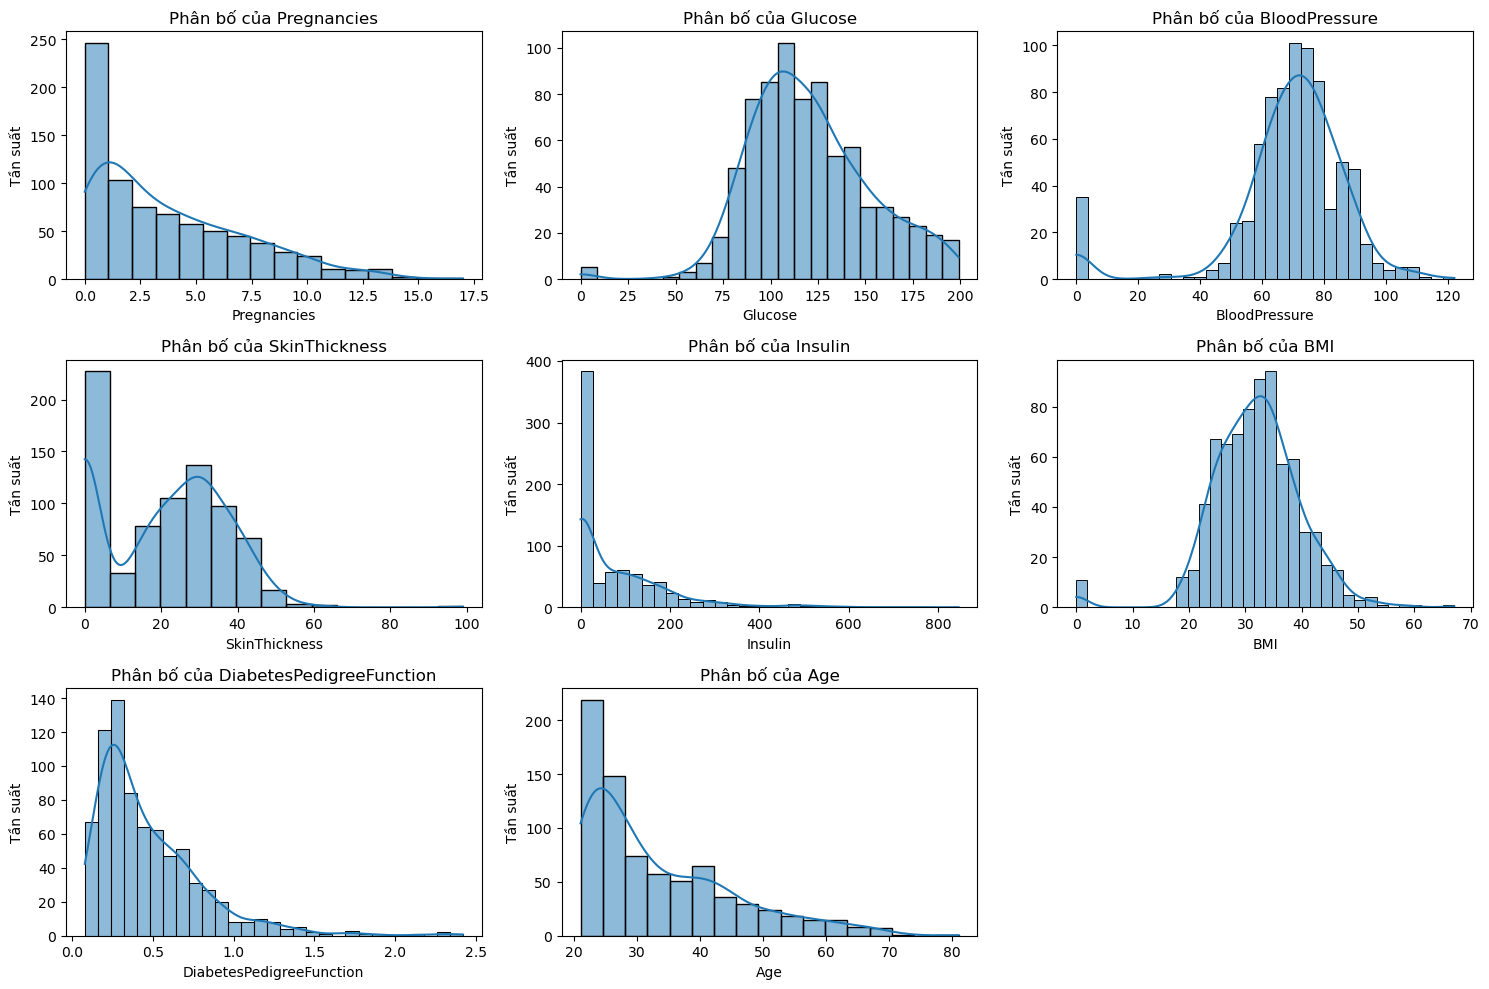

In [16]:
# 4. Trực quan hóa Phân bố Dữ liệu (Histograms)

# Xác định các cột số để vẽ histogram
# Loại trừ cột 'Outcome' vì nó là biến phân loại (0 hoặc 1)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Outcome')

# Thiết lập kích thước figure và số lượng subplot
plt.figure(figsize=(15, 10))

# Lặp qua từng cột số và vẽ histogram
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Tạo lưới 3x3 cho các histogram
    sns.histplot(df[col], kde=True) # Vẽ histogram với đường ước tính mật độ hạt nhân (KDE)
    plt.title(f'Phân bố của {col}') # Đặt tiêu đề cho từng histogram
    plt.xlabel(col)
    plt.ylabel('Tần suất')

plt.tight_layout() # Tự động điều chỉnh khoảng cách giữa các subplot
plt.show()


## 5. Xác định Outliers bằng Boxplots


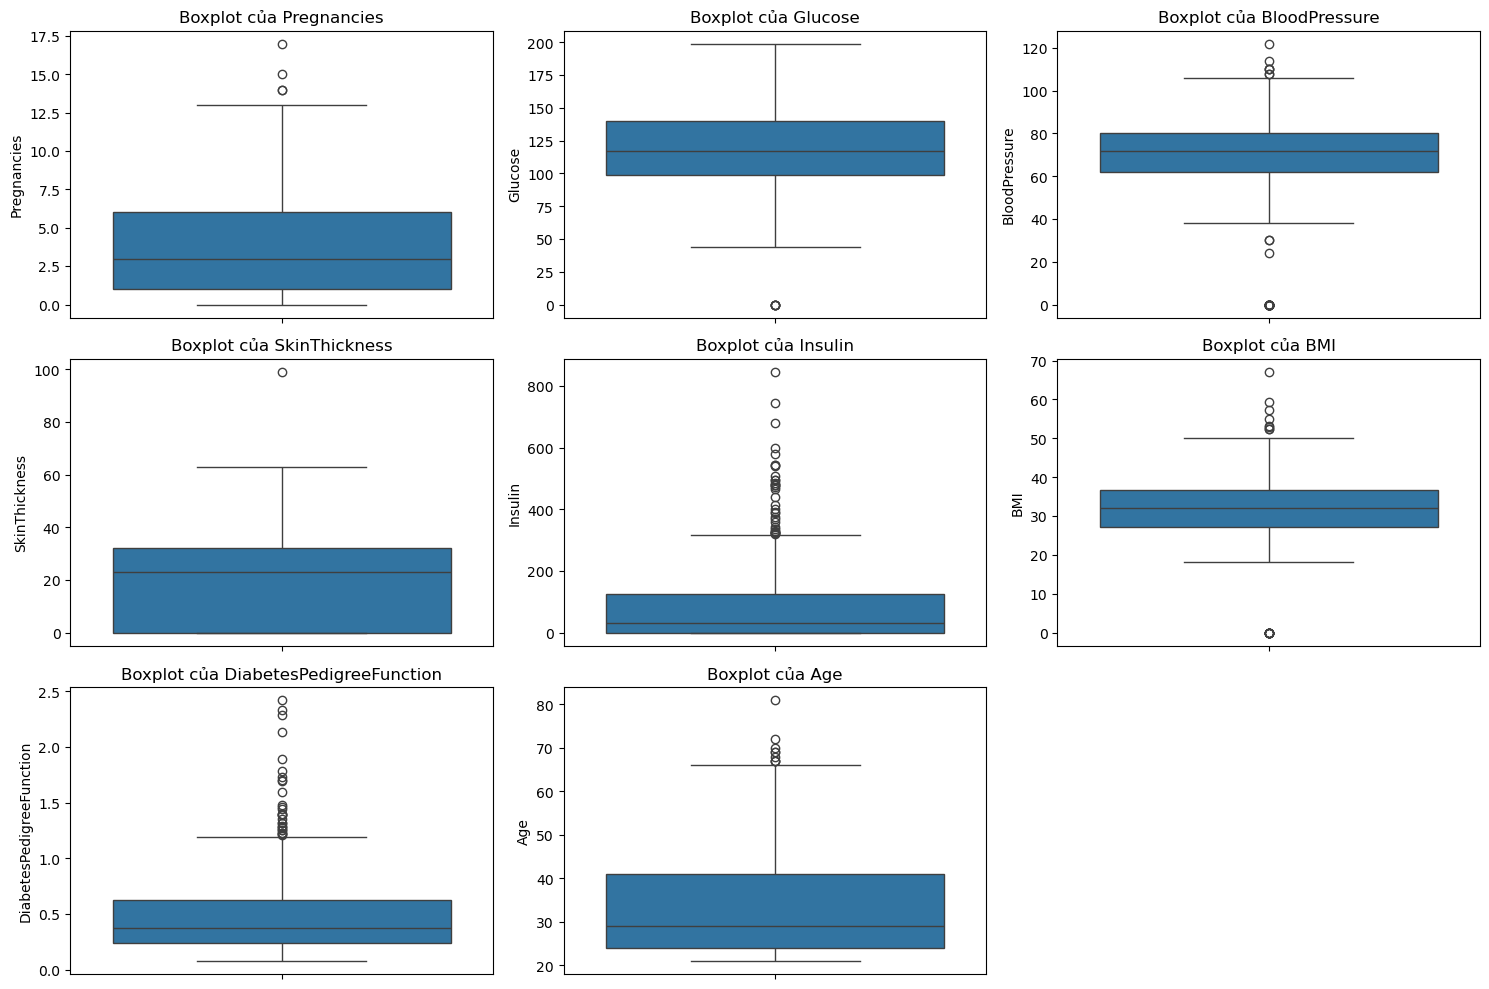

In [17]:
# 5. Xác định Outliers bằng Boxplots

# Xác định các cột số để vẽ boxplot
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Outcome') # Loại trừ cột 'Outcome'

# Thiết lập kích thước figure và số lượng subplot
plt.figure(figsize=(15, 10))

# Lặp qua từng cột số và vẽ boxplot
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Tạo lưới 3x3 cho các boxplot
    sns.boxplot(y=df[col]) # Vẽ boxplot
    plt.title(f'Boxplot của {col}') # Đặt tiêu đề cho từng boxplot
    plt.ylabel(col)

plt.tight_layout() # Tự động điều chỉnh khoảng cách giữa các subplot
plt.show()


## 6. Phân tích Tương quan


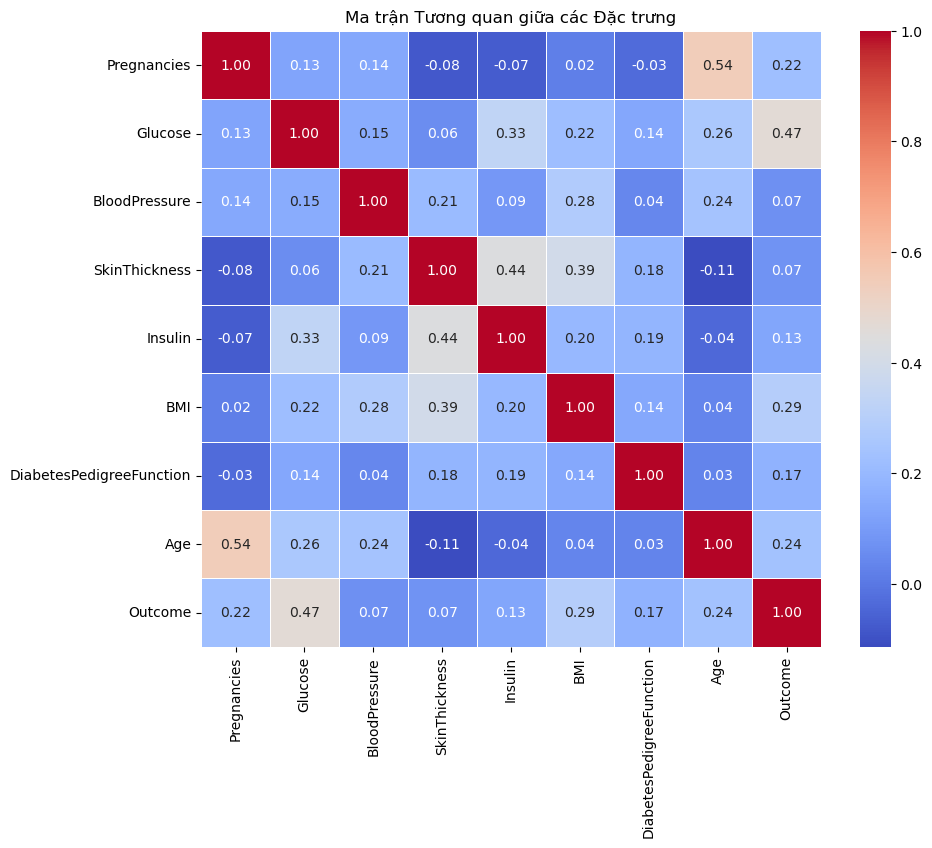

In [18]:
# 6. Phân tích Tương quan

# Tính toán ma trận tương quan
correlation_matrix = df.corr()

# Thiết lập kích thước figure
plt.figure(figsize=(10, 8))

# Vẽ heatmap của ma trận tương quan
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # annot=True để hiển thị giá trị, cmap để chọn màu, fmt để định dạng số
plt.title('Ma trận Tương quan giữa các Đặc trưng') # Đặt tiêu đề
plt.show()

